## Summary

This analysis of the Iris dataset demonstrates:

1. **Dataset Structure**: The dataset contains 150 samples with 5 columns (4 numerical features and 1 categorical species label).
2. **Feature Relationships**: Scatter plots reveal strong correlations between petal measurements and species, showing clear separation between species.
3. **Data Distribution**: Histograms show that the features follow approximately normal distributions, with some variation across species.
4. **Outliers and Spread**: Box plots reveal minimal outliers in the dataset, indicating good data quality. Each species has distinct ranges for the measured features.

In [13]:
# Identify outliers using IQR method
print("\n" + "=" * 50)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 50)

def identify_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Check for outliers in each numerical column
for col in numerical_cols:
    count, lower, upper = identify_outliers(iris_df, col)
    print(f"\n{col.upper()}:")
    print(f"  - Outliers found: {count}")
    print(f"  - Lower bound: {lower:.2f}")
    print(f"  - Upper bound: {upper:.2f}")


OUTLIER DETECTION (IQR Method)

SEPAL_LENGTH:
  - Outliers found: 0
  - Lower bound: 3.15
  - Upper bound: 8.35

SEPAL_WIDTH:
  - Outliers found: 4
  - Lower bound: 2.05
  - Upper bound: 4.05

PETAL_LENGTH:
  - Outliers found: 0
  - Lower bound: -3.65
  - Upper bound: 10.35

PETAL_WIDTH:
  - Outliers found: 0
  - Lower bound: -1.95
  - Upper bound: 4.05


/tmp/ipykernel_24326/827265744.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris_df, x='species', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_24326/827265744.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris_df, x='species', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_24326/827265744.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris_df, x='species', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_24326/827265744.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

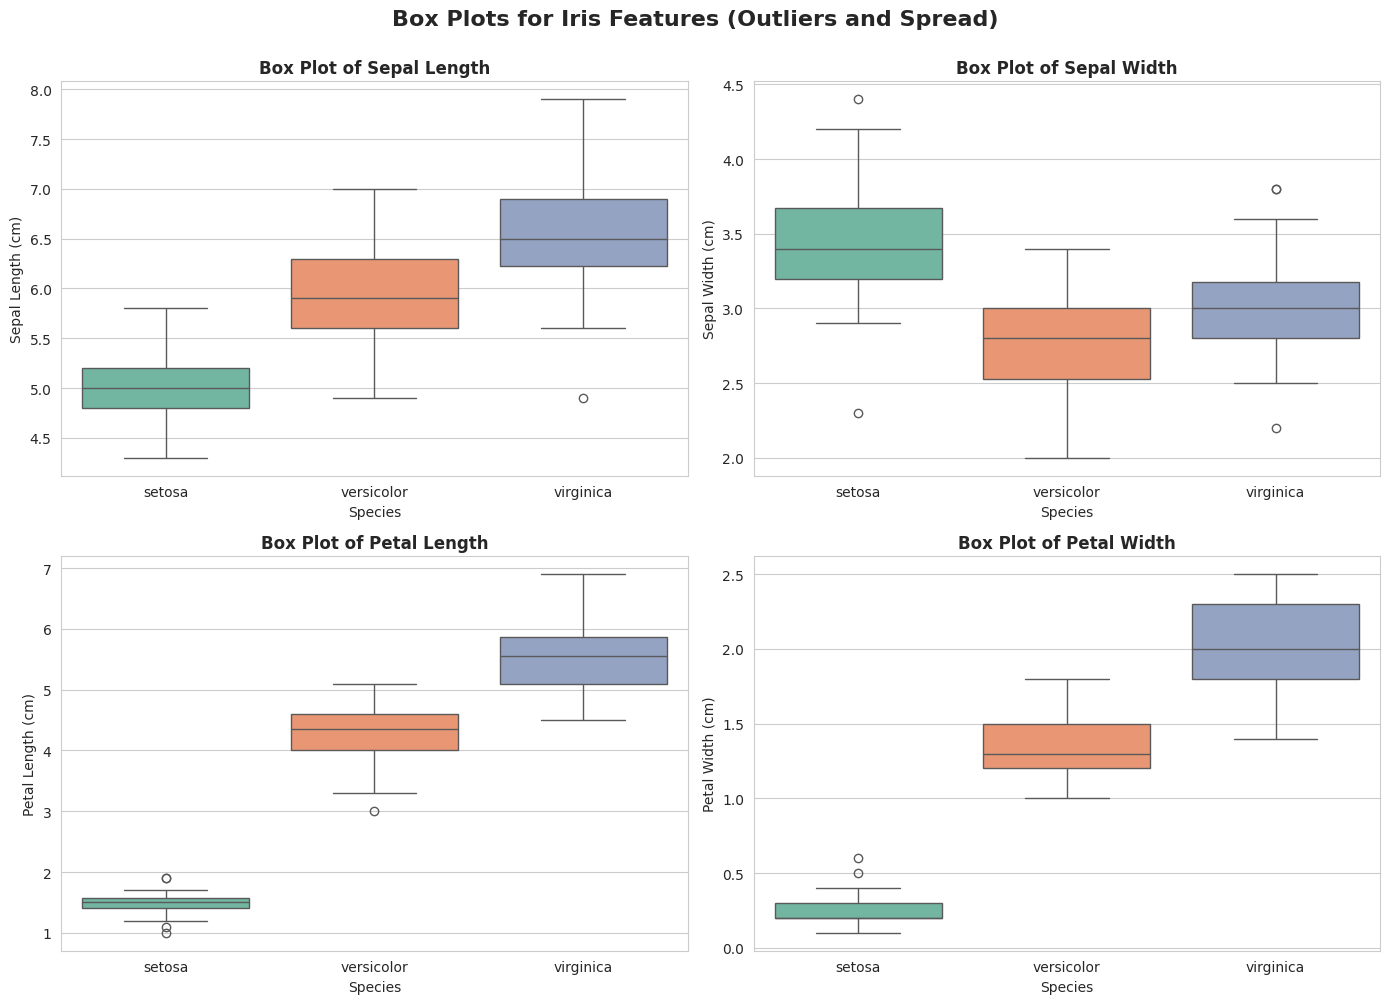

In [12]:
# Create a figure with subplots for box plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Box Plots for Iris Features (Outliers and Spread)', fontsize=16, fontweight='bold', y=1.00)

# Plot box plots for each numerical feature
for idx, col in enumerate(numerical_cols):
    row = idx // 2
    col_idx = idx % 2
    ax = axes[row, col_idx]
    
    # Create box plot with seaborn
    sns.boxplot(data=iris_df, x='species', y=col, ax=ax, palette='Set2')
    ax.set_title(f'Box Plot of {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Species', fontsize=10)
    ax.set_ylabel(f'{col.replace("_", " ").title()} (cm)', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Box Plot: Outliers and Spread

Create box plots for each numerical feature to detect outliers and visualize the spread of values across different species.

/tmp/ipykernel_24326/3674760023.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Species', fontsize=9)
/tmp/ipykernel_24326/3674760023.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Species', fontsize=9)
/tmp/ipykernel_24326/3674760023.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Species', fontsize=9)
/tmp/ipykernel_24326/3674760023.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Species', fontsize=9)


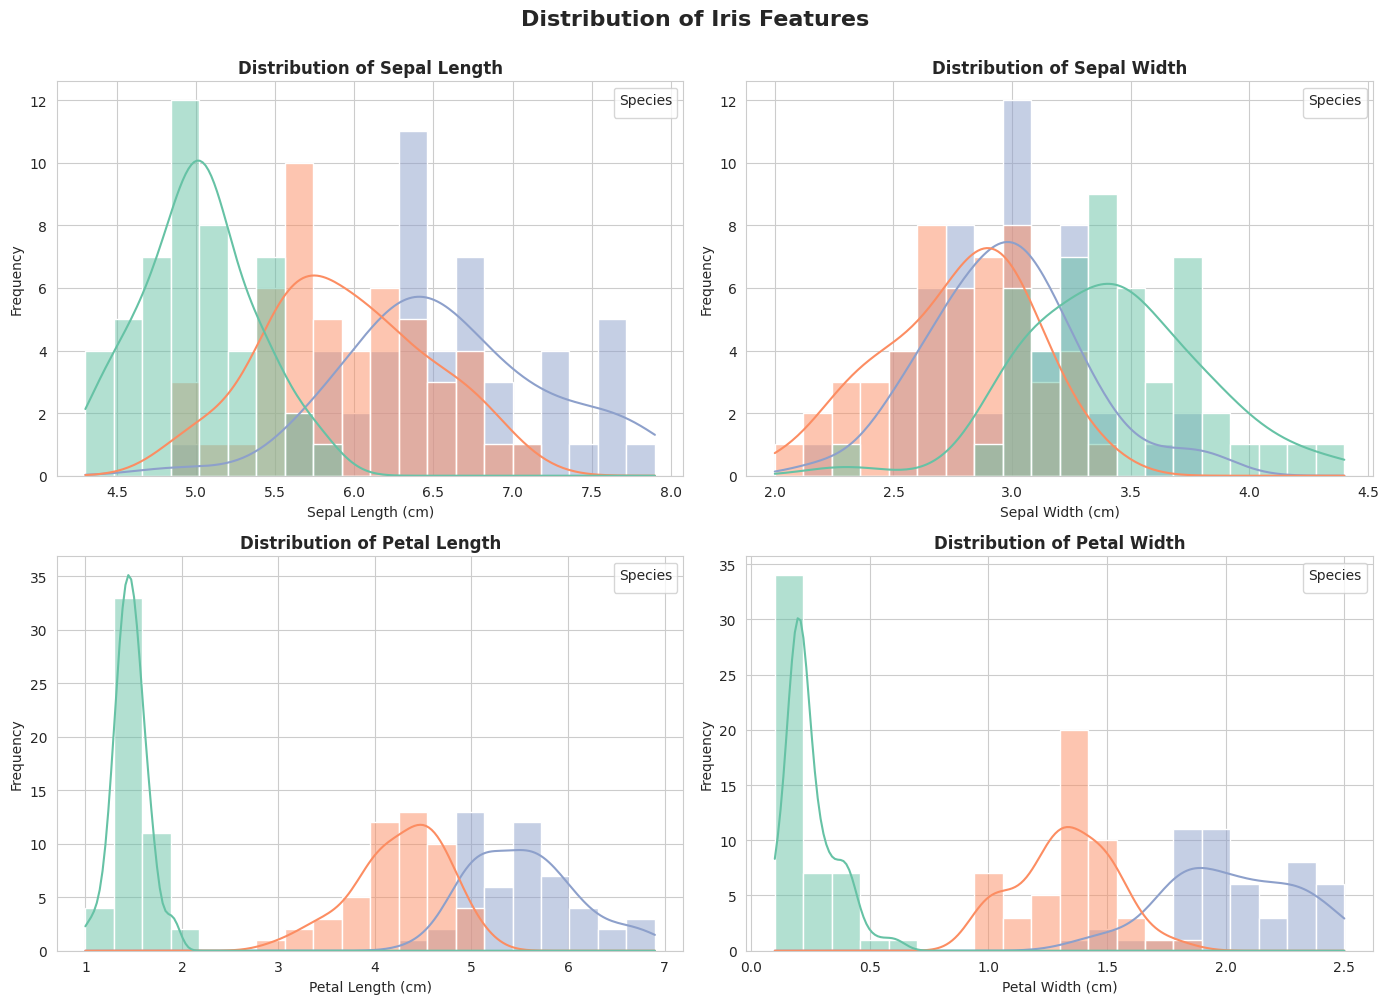

In [11]:
# Create a figure with subplots for all histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Iris Features', fontsize=16, fontweight='bold', y=1.00)

# Get numerical columns
numerical_cols = iris_df.select_dtypes(include=['float64', 'int64']).columns

# Plot histograms for each numerical feature
for idx, col in enumerate(numerical_cols):
    row = idx // 2
    col_idx = idx % 2
    ax = axes[row, col_idx]
    
    # Create histogram with seaborn
    sns.histplot(data=iris_df, x=col, hue='species', kde=True, ax=ax, palette='Set2', bins=20)
    ax.set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{col.replace("_", " ").title()} (cm)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(title='Species', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Histogram: Data Distribution

Plot histograms for each numerical feature to examine their distributions.

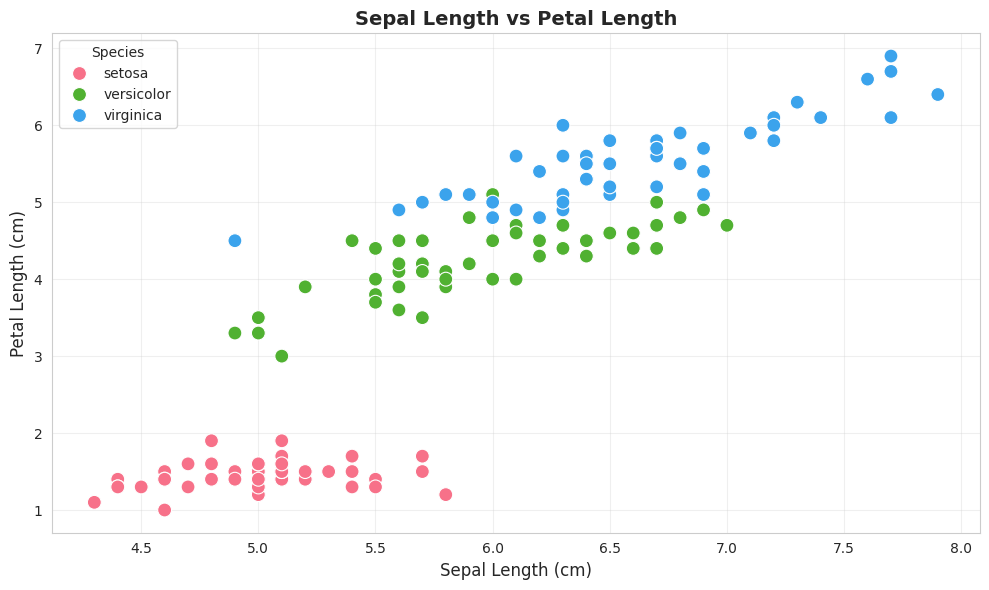

In [10]:
# Scatter plot: Sepal Length vs Petal Length
plt.figure(figsize=(10, 6))
sns.scatterplot(data=iris_df, x='sepal_length', y='petal_length', hue='species', s=100, palette='husl')
plt.title('Sepal Length vs Petal Length', fontsize=14, fontweight='bold')
plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Petal Length (cm)', fontsize=12)
plt.legend(title='Species', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

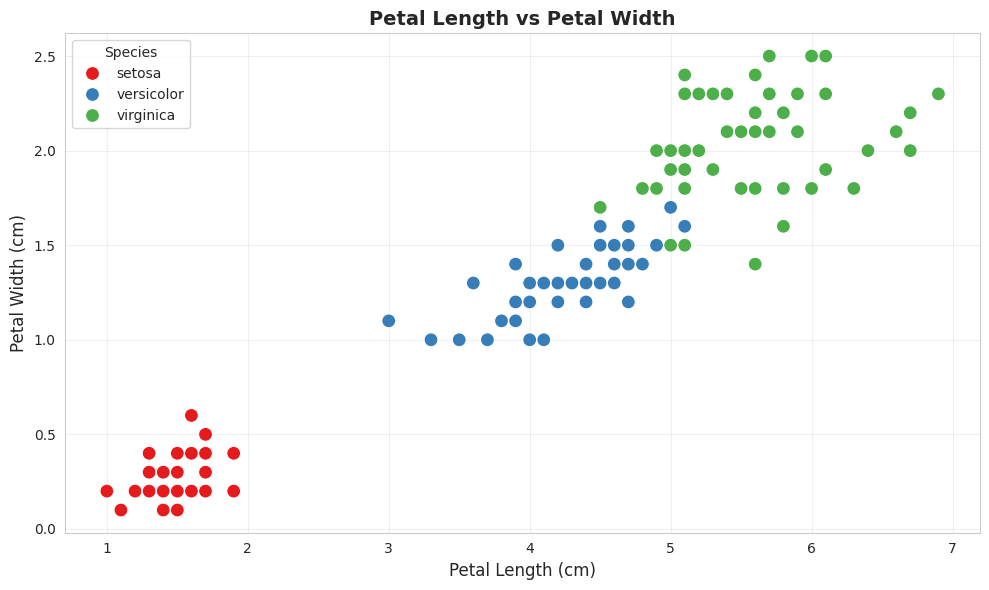

In [9]:
# Scatter plot: Petal Length vs Petal Width
plt.figure(figsize=(10, 6))
sns.scatterplot(data=iris_df, x='petal_length', y='petal_width', hue='species', s=100, palette='Set1')
plt.title('Petal Length vs Petal Width', fontsize=14, fontweight='bold')
plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.legend(title='Species', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

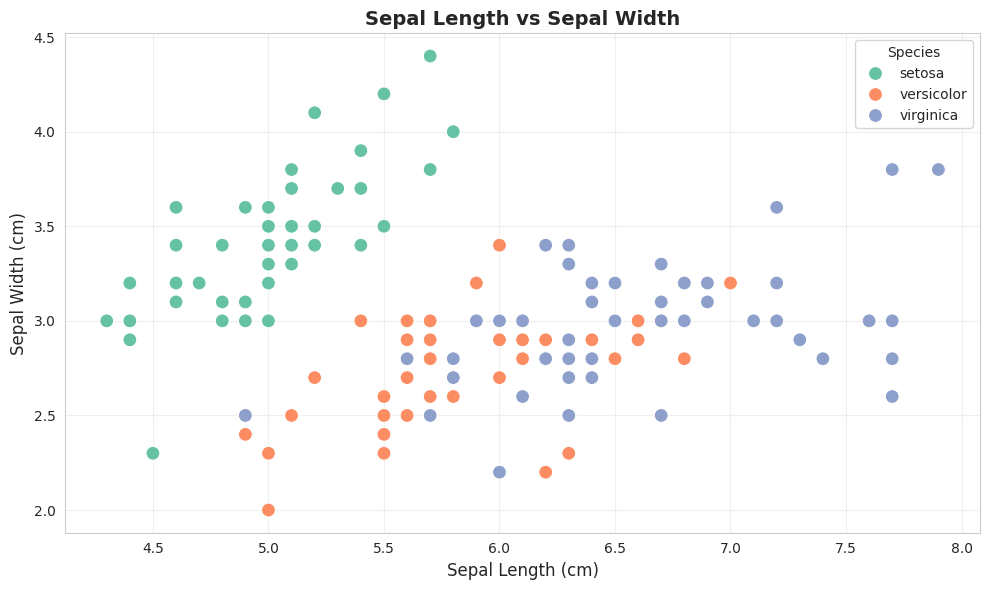

In [8]:
# Scatter plot: Sepal Length vs Sepal Width
plt.figure(figsize=(10, 6))
sns.scatterplot(data=iris_df, x='sepal_length', y='sepal_width', hue='species', s=100, palette='Set2')
plt.title('Sepal Length vs Sepal Width', fontsize=14, fontweight='bold')
plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Sepal Width (cm)', fontsize=12)
plt.legend(title='Species', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Scatter Plot: Variable Relationships

Create scatter plots to analyze relationships between pairs of variables in the dataset. We'll examine how different features correlate with each other, colored by species.

In [7]:
# Display statistical summary
print("\n" + "=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
print(iris_df.describe())


STATISTICAL SUMMARY
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [6]:
# Display data types and missing values
print("\n" + "=" * 50)
print("DATA TYPES AND INFO")
print("=" * 50)
print(iris_df.info())


DATA TYPES AND INFO
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None


In [5]:
# Display first few rows
print("\n" + "=" * 50)
print("FIRST 5 ROWS (head())")
print("=" * 50)
print(iris_df.head())


FIRST 5 ROWS (head())
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
# Display column names
print("\n" + "=" * 50)
print("COLUMN NAMES")
print("=" * 50)
print(iris_df.columns.tolist())


COLUMN NAMES
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [3]:
# Display dataset shape
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Shape: {iris_df.shape}")
print(f"Number of rows: {iris_df.shape[0]}")
print(f"Number of columns: {iris_df.shape[1]}")


DATASET SHAPE
Shape: (150, 5)
Number of rows: 150
Number of columns: 5


## 3. Explore Dataset Structure

Display the shape, column names, and the first few rows of the dataset.

In [2]:
# Load the Iris dataset from seaborn
iris_df = sns.load_dataset('iris')

# Display basic information about the dataset
print("Dataset loaded successfully!")
print(f"Dataset type: {type(iris_df)}")

Dataset loaded successfully!
Dataset type: <class 'pandas.DataFrame'>


## 2. Load the Iris Dataset

Load the Iris dataset into a pandas DataFrame using seaborn's built-in dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Import Required Libraries

Import pandas for data handling, and matplotlib.pyplot and seaborn for visualizations.

# Exploring and Visualizing the Iris Dataset

This notebook provides a comprehensive analysis of the Iris dataset, including data loading, structure exploration, and various visualizations to understand relationships, distributions, and outliers.